# Import libaries and create the global dataframe

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_error , mean_squared_error
import warnings
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')

In [ ]:
df  = pd.read_csv('/content/portfolio_data.csv')
df.columns = ['Date', 'AMZN', 'DPZ', 'BTC', 'NFLX']
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date' , inplace = True)

df.head()



,AMZN,DPZ,BTC,NFLX
Date,,,,
2013-05-01,248.229996,51.190983,106.250000,30.415714
2013-05-02,252.550003,51.987320,98.099998,30.641428
2013-05-03,258.049988,52.446388,112.900002,30.492857
2013-05-06,255.720001,53.205257,109.599998,30.098572
2013-05-07,257.730011,54.151505,113.199997,29.464285


# Split the Stock Market to predict each Market **separetelly**

In [ ]:
df_amzn = df[['AMZN']]
df_dpz = df[['DPZ']]
df_btc = df[['BTC']]
df_nflx = df[['NFLX']]

## Visualize the time series

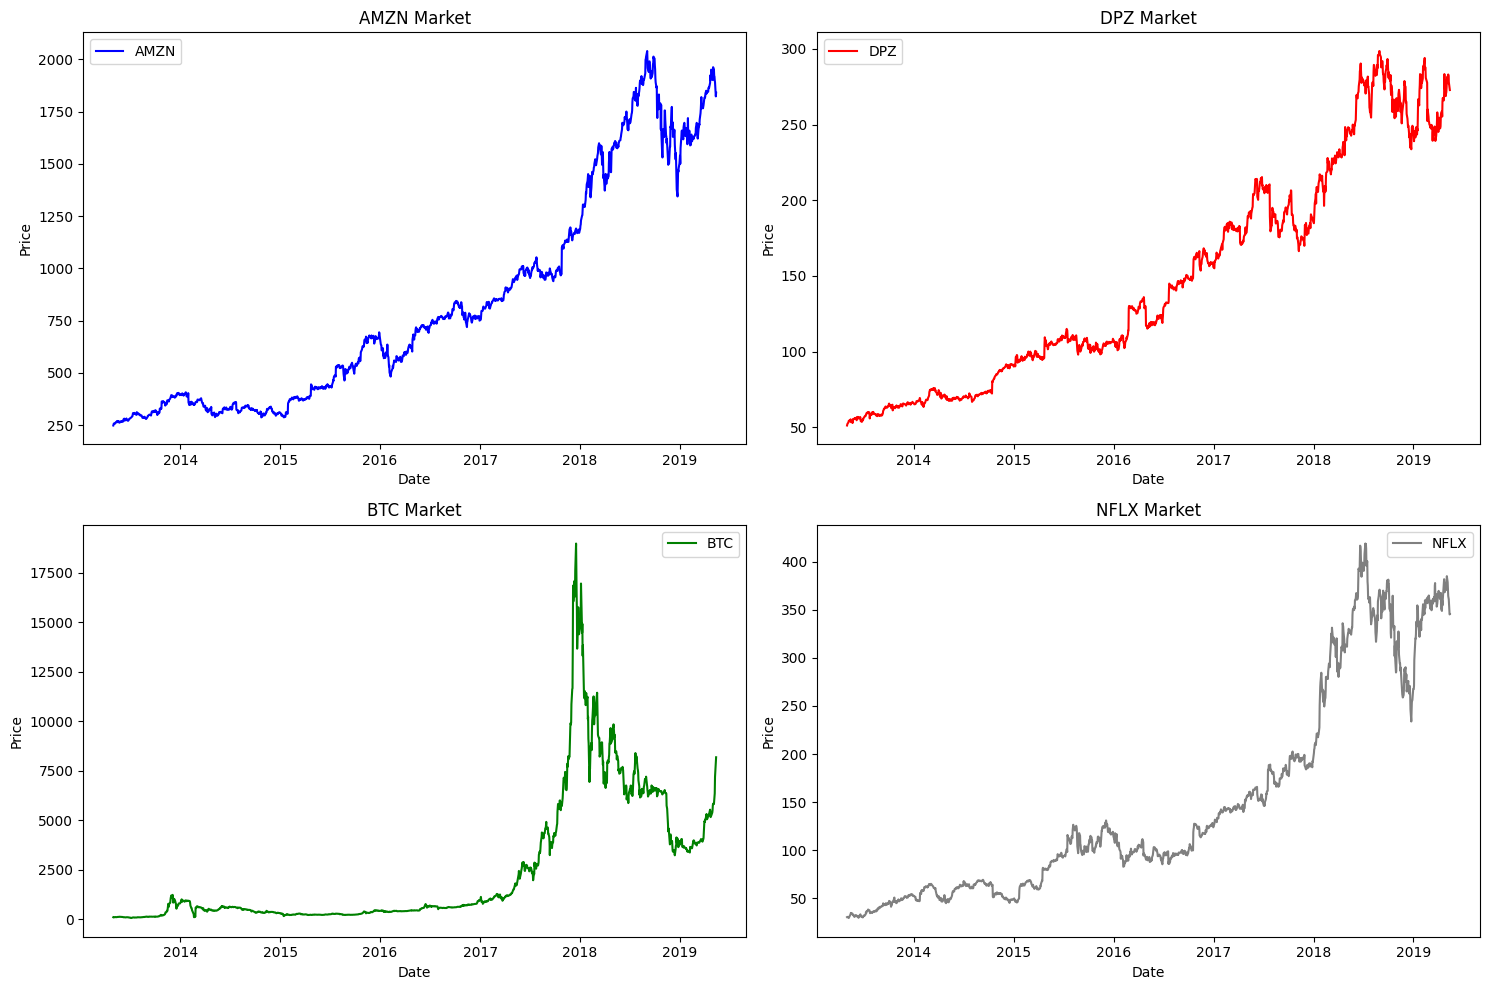

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))


axes[0, 0].plot(df_amzn, label='AMZN', color='blue')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price')
axes[0, 0].set_title('AMZN Market')
axes[0, 0].legend()


axes[0, 1].plot(df_dpz, label='DPZ', color='red')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Price')
axes[0, 1].set_title('DPZ Market')
axes[0, 1].legend()

axes[1, 0].plot(df_btc, label='BTC', color='green')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Price')
axes[1, 0].set_title('BTC Market')
axes[1, 0].legend()

axes[1, 1].plot(df_nflx, label='NFLX', color='gray')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Price')
axes[1, 1].set_title('NFLX Market')
axes[1, 1].legend()

plt.tight_layout()

plt.show()


#Stationarity

In [ ]:
resultsA = adfuller(df_amzn['AMZN'])
print('AMZN market -------------')
print('ADF stat ' , resultsA[0])
print('p-value' , resultsA[1])

if resultsA[1] <= 0.05:
  print('The time series is stationary')
else:
  print('The time series is not stationary')


resultsD = adfuller(df_dpz['DPZ'])
print('DPZ market -------------')
print('ADF stat ' , resultsD[0])
print('p-value' , resultsD[1])

if resultsD[1] <= 0.05:
  print('The time series is stationary')
else:
  print('The time series is not stationary')




resultsB = adfuller(df_btc['BTC'])
print('BTC market -------------')
print('ADF stat ' , resultsB[0])
print('p-value' , resultsB[1])

if resultsB[1] <= 0.05:
  print('The time series is stationary')
else:
  print('The time series is not stationary')



resultsN = adfuller(df_nflx['NFLX'])
print('NFLX market -------------')
print('ADF stat ' , resultsN[0])
print('p-value' , resultsN[1])

if resultsN[1] <= 0.05:
  print('The time series is stationary')
else:
  print('The time series is not stationary')

AMZN market -------------
ADF stat  0.55365991233002
p-value 0.9864159495725892
The time series is not stationary
DPZ market -------------
ADF stat  -0.2793349606892411
p-value 0.9283805552655593
The time series is not stationary
BTC market -------------
ADF stat  -1.323081119891322
p-value 0.6185476417504847
The time series is not stationary
NFLX market -------------
ADF stat  -0.1841581933608912
p-value 0.9403837629187612
The time series is not stationary


In [ ]:
"""
market not stationary we need to make it stationary
"""

df_amzn['AMZN_diff'] = df_amzn['AMZN'].diff()
df_amzn.dropna(inplace = True)

df_dpz['DPZ_diff'] = df_dpz['DPZ'].diff()
df_dpz.dropna(inplace = True)

df_btc['BTC_diff'] = df_btc['BTC'].diff()
df_btc.dropna(inplace = True)

df_nflx['NFLX_diff'] = df_nflx['NFLX'].diff()
df_nflx.dropna(inplace = True)

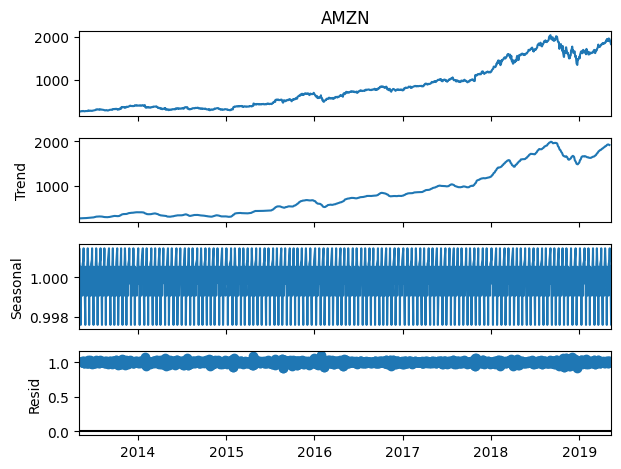

In [ ]:
decompose_amzn = seasonal_decompose(df_amzn['AMZN'] , model = 'multiplicative' , period=12)
decompose_amzn.plot()
plt.show()

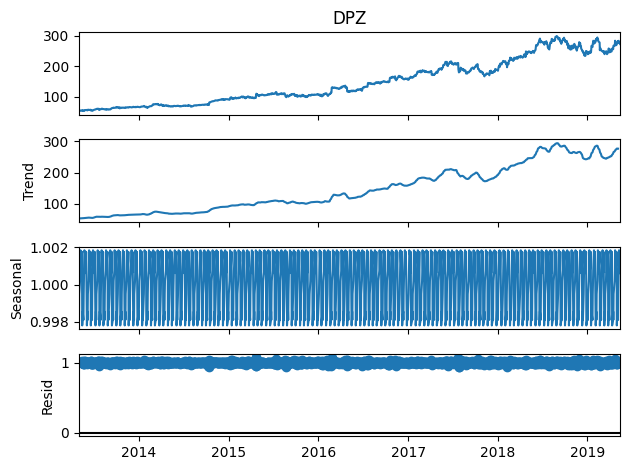

In [ ]:
decompose_dpz = seasonal_decompose(df_dpz['DPZ'] , model = 'multiplicative' , period=12)
decompose_dpz.plot()
plt.show()


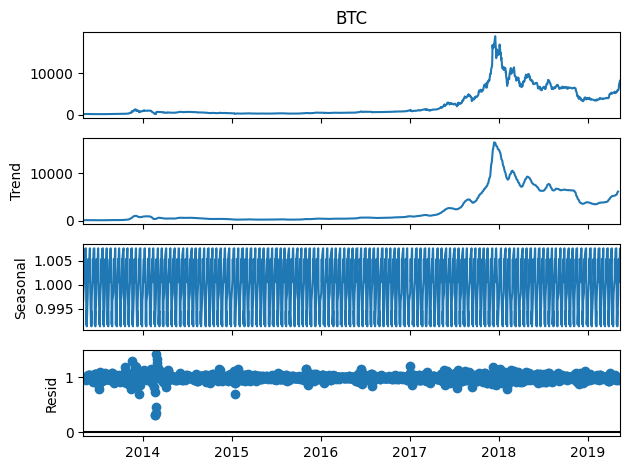

In [ ]:
decompose_btc = seasonal_decompose(df_btc['BTC'] , model = 'multiplicative' , period=12)
decompose_btc.plot()
plt.show()

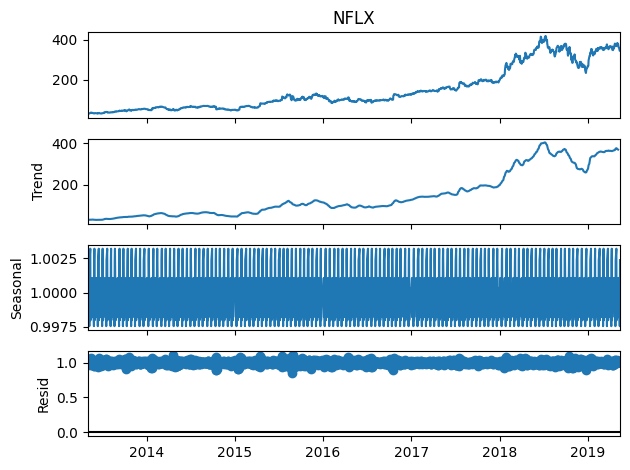

In [ ]:

decompose_nflx = seasonal_decompose(df_nflx['NFLX'] , model = 'multiplicative' , period=12)
decompose_nflx.plot()
plt.show()

#Building models

## ARIMA model


Forecasted values: 1519    1839.684694
1520    1833.871809
1521    1828.073269
1522    1827.557631
1523    1832.685322
1524    1838.681576
1525    1840.080117
1526    1835.704245
1527    1829.648267
1528    1827.449335
1529    1831.026582
1530    1837.011336
Name: predicted_mean, dtype: float64


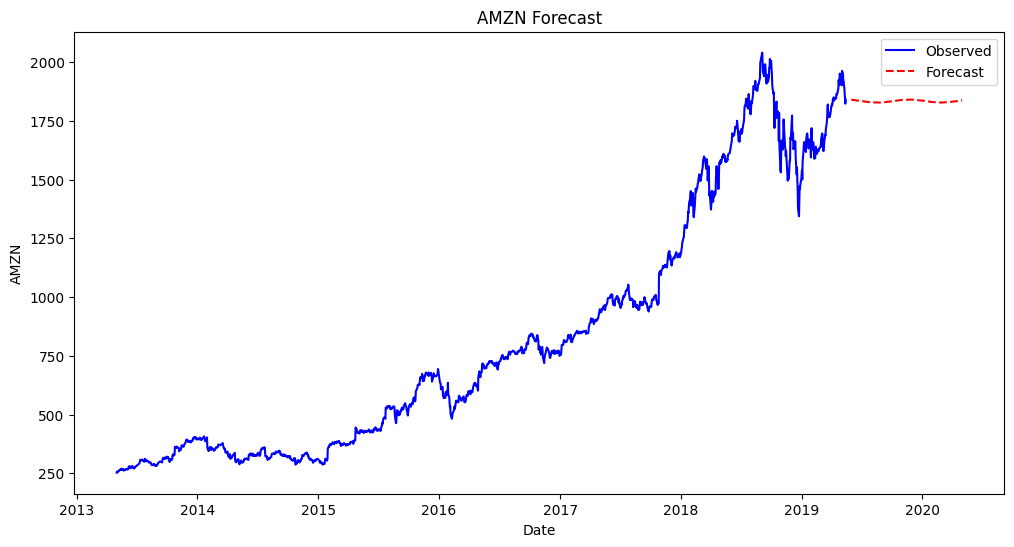

In [ ]:

model_amzn = ARIMA(df_amzn['AMZN'] , order = (2,1,2))
model_amzn_fit = model_amzn.fit()


forecastA = model_amzn_fit.forecast(steps = 12)
print("Forecasted values:", forecastA)

# Generate the dates for the forecasted periods
forecast_index = pd.date_range(start=df_amzn.index[-1], periods=12, freq='M')

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df_amzn.index, df_amzn['AMZN'], label='Observed', color='blue')
plt.plot(forecast_index, forecastA, label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('AMZN')
plt.title('AMZN Forecast')
plt.legend()
plt.show()


Forecasted values: 1519    273.293976
1520    274.320664
1521    273.971439
1522    272.922208
1523    273.185310
1524    274.250049
1525    274.073853
1526    273.000669
1527    273.089746
1528    274.164334
1529    274.162023
1530    273.093004
Name: predicted_mean, dtype: float64


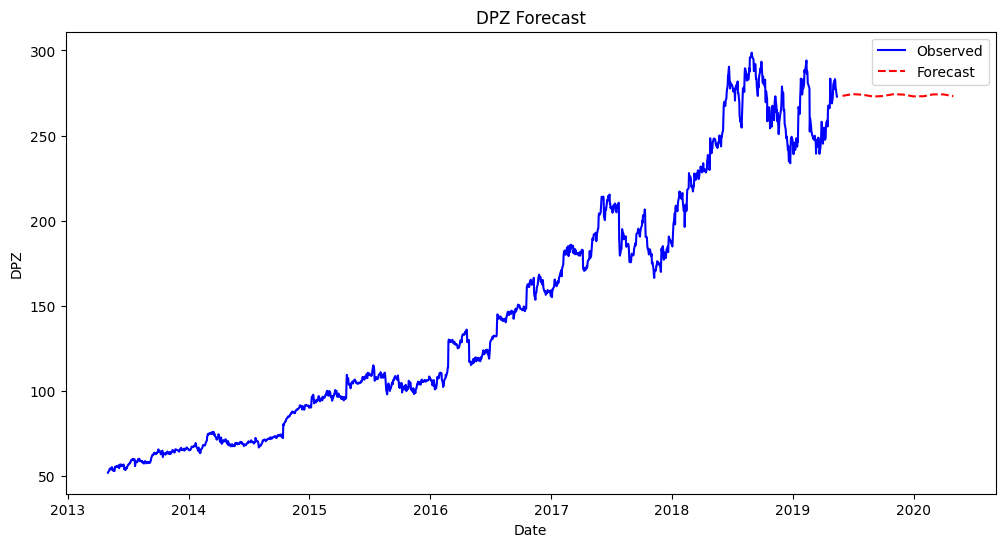

In [ ]:

model_dpz = ARIMA(df_dpz['DPZ'] , order = (2,1,2))
model_dpz_fit = model_dpz.fit()


forecastD = model_dpz_fit.forecast(steps = 12)
print("Forecasted values:", forecastD)

# Generate the dates for the forecasted periods
forecast_index = pd.date_range(start=df_dpz.index[-1], periods=12, freq='M')

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df_dpz.index, df_dpz['DPZ'], label='Observed', color='blue')
plt.plot(forecast_index, forecastD, label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('DPZ')
plt.title('DPZ Forecast')
plt.legend()
plt.show()





Forecasted values: 1519    344.481139
1520    343.669803
1521    343.366964
1522    343.609163
1523    344.282384
1524    345.166280
1525    346.003198
1526    346.571137
1527    346.740569
1528    346.501207
1529    345.954163
1530    345.274693
Name: predicted_mean, dtype: float64


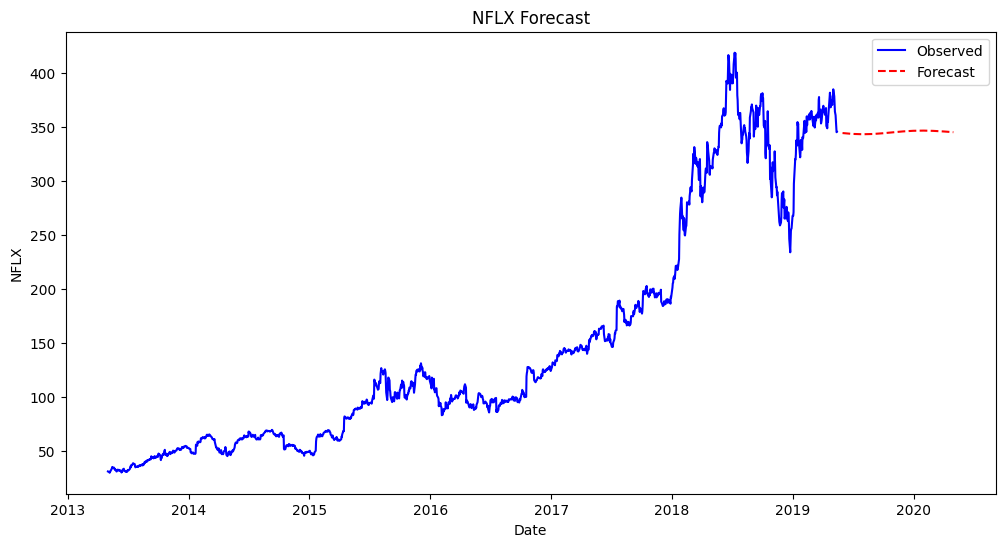

In [ ]:
model_nflx = ARIMA(df_nflx['NFLX'] , order = (2,1,2))
model_nflx_fit = model_nflx.fit()

forecastN = model_nflx_fit.forecast(steps = 12)
print("Forecasted values:", forecastN)

forecast_index = pd.date_range(start=df_nflx.index[-1], periods=12, freq='M')

plt.figure(figsize=(12, 6))
plt.plot(df_nflx.index, df_nflx['NFLX'], label='Observed', color='blue')
plt.plot(forecast_index, forecastN, label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('NFLX')
plt.title('NFLX Forecast')
plt.legend()
plt.show()

Forecasted values: 1519    8320.414178
1520    8439.369341
1521    8529.557838
1522    8597.734227
1523    8649.267459
1524    8688.220386
1525    8717.664114
1526    8739.920030
1527    8756.742826
1528    8769.458837
1529    8779.070611
1530    8786.335957
Name: predicted_mean, dtype: float64


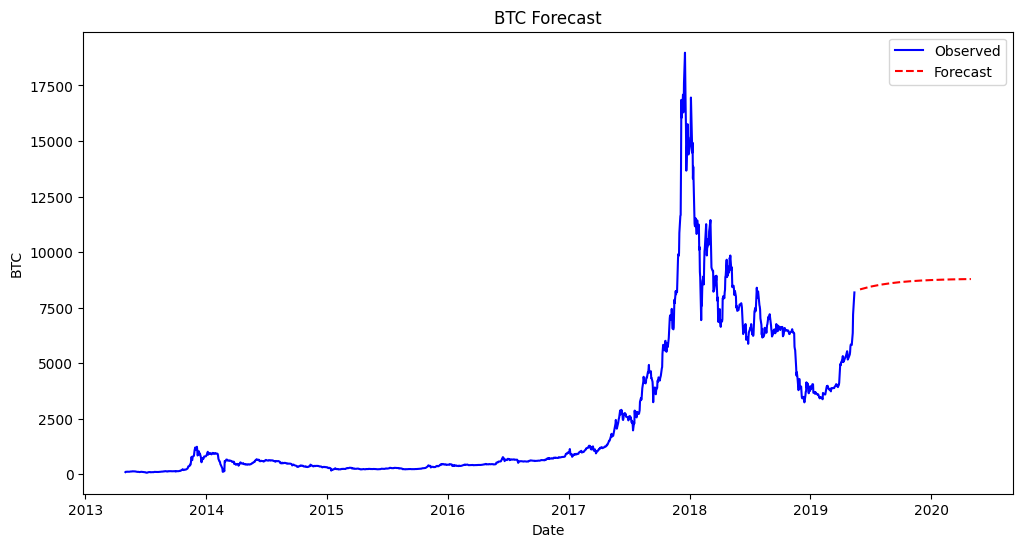

In [ ]:
model_btc = ARIMA(df_btc['BTC'] , order = (2,1,2))
model_btc_fit = model_btc.fit()


forecastB = model_btc_fit.forecast(steps = 12)
print("Forecasted values:", forecastB)

# Generate the dates for the forecasted periods
forecast_index = pd.date_range(start=df_btc.index[-1], periods=12, freq='M')

# Plot the results

plt.figure(figsize=(12, 6))
plt.plot(df_btc.index, df_btc['BTC'], label='Observed', color='blue')
plt.plot(forecast_index, forecastB, label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('BTC')
plt.title('BTC Forecast')
plt.legend()
plt.show()


In [ ]:
"""
ARIMA evaluation
"""

y_true = df['AMZN'][-12:]
y_pred = forecastA

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
print('AMZN ------')
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)


y_true = df['DPZ'][-12:]
y_pred = forecastD

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
print('DPZ ------')
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)


y_true = df['NFLX'][-12:]
y_pred = forecastN

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
print('NFLX ------')
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

y_true = df['BTC'][-12:]
y_pred = forecastB

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
print('BTC ------')
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)


AMZN ------
MAE: 74.74491394282383
MSE: 6852.033019337679
RMSE: 82.77700779405885
DPZ ------
MAE: 4.472081590976681
MSE: 29.94911178095461
RMSE: 5.472578165814958
NFLX ------
MAE: 22.76646670694989
MSE: 679.0844273052265
RMSE: 26.059248402538906
BTC ------
MAE: 2352.9621536456275
MSE: 6228111.480714545
RMSE: 2495.6184565583226


## Prophet model

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcfag4flf/3zqc1brh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcfag4flf/7c2n1p6w.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=42811', 'data', 'file=/tmp/tmpcfag4flf/3zqc1brh.json', 'init=/tmp/tmpcfag4flf/7c2n1p6w.json', 'output', 'file=/tmp/tmpcfag4flf/prophet_models3fndnc0/prophet_model-20250211091456.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:14:56 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:14:56 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


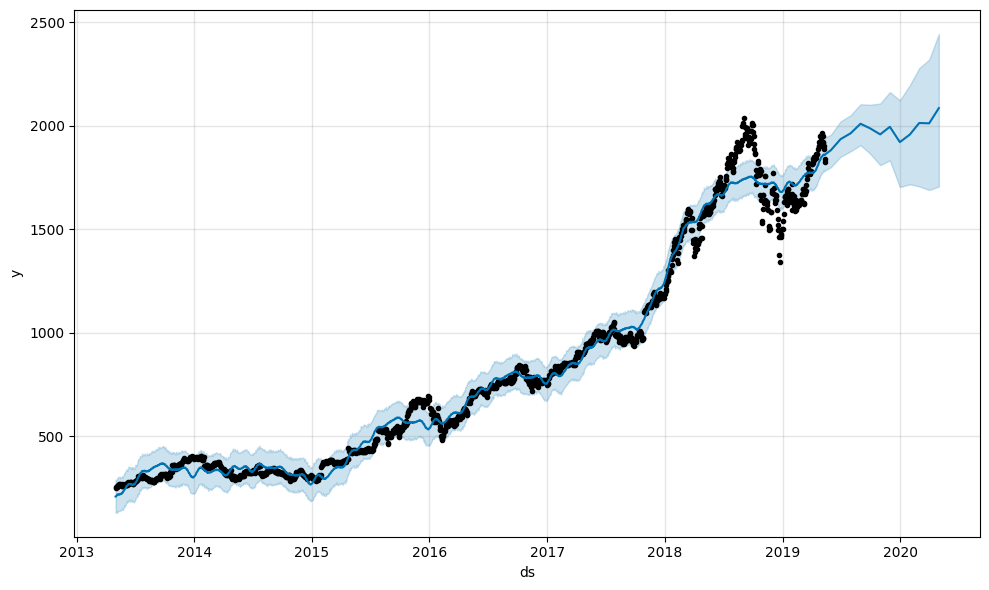

In [ ]:
df_amzn_prophet = df_amzn['AMZN'].reset_index()
df_amzn_prophet.columns = ['ds' , 'y']

model_amzn_prophet = Prophet()
model_amzn_prophet.fit(df_amzn_prophet)

future_amzn = model_amzn_prophet.make_future_dataframe(periods = 12 , freq = 'M')
forecast_amzn = model_amzn_prophet.predict(future_amzn)

model_amzn_prophet.plot(forecast_amzn)
plt.show()


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcfag4flf/st4dgvj0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcfag4flf/2_rd7e5d.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=72633', 'data', 'file=/tmp/tmpcfag4flf/st4dgvj0.json', 'init=/tmp/tmpcfag4flf/2_rd7e5d.json', 'output', 'file=/tmp/tmpcfag4flf/prophet_model_skp1zjc/prophet_model-20250211091457.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:14:57 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:14:58 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


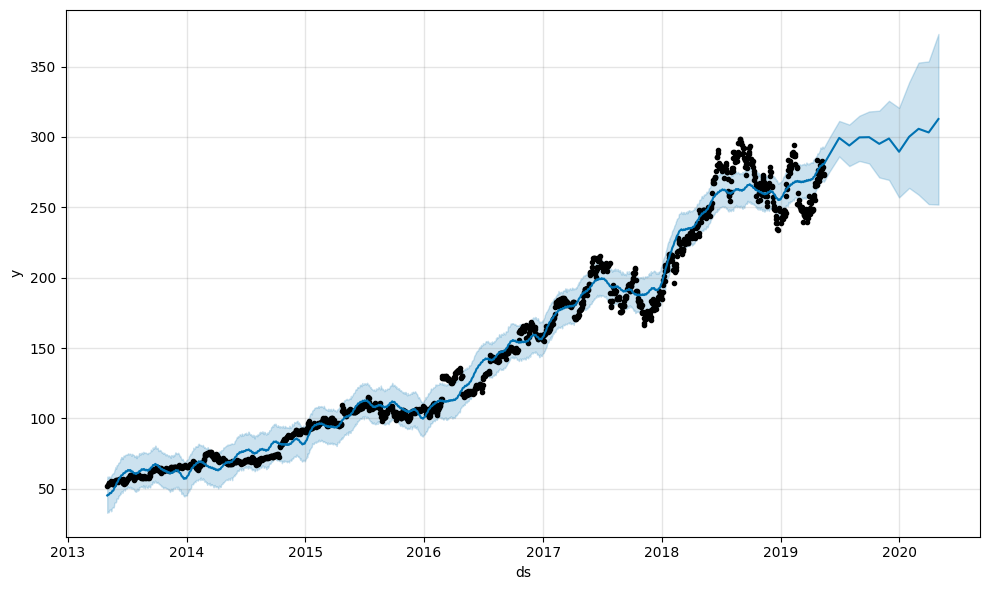

In [ ]:
df_dpz_prophet = df_dpz['DPZ'].reset_index()
df_dpz_prophet.columns = ['ds' , 'y']


model_dpz_prophet = Prophet()
model_dpz_prophet.fit(df_dpz_prophet)

future_dpz = model_dpz_prophet.make_future_dataframe(periods = 12 , freq = 'M')
forecast_dpz = model_dpz_prophet.predict(future_dpz)

model_dpz_prophet.plot(forecast_dpz)
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcfag4flf/7agnfk7c.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcfag4flf/vpzlndj7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=56582', 'data', 'file=/tmp/tmpcfag4flf/7agnfk7c.json', 'init=/tmp/tmpcfag4flf/vpzlndj7.json', 'output', 'file=/tmp/tmpcfag4flf/prophet_modelid62n5h9/prophet_model-20250211091459.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:14:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:14:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


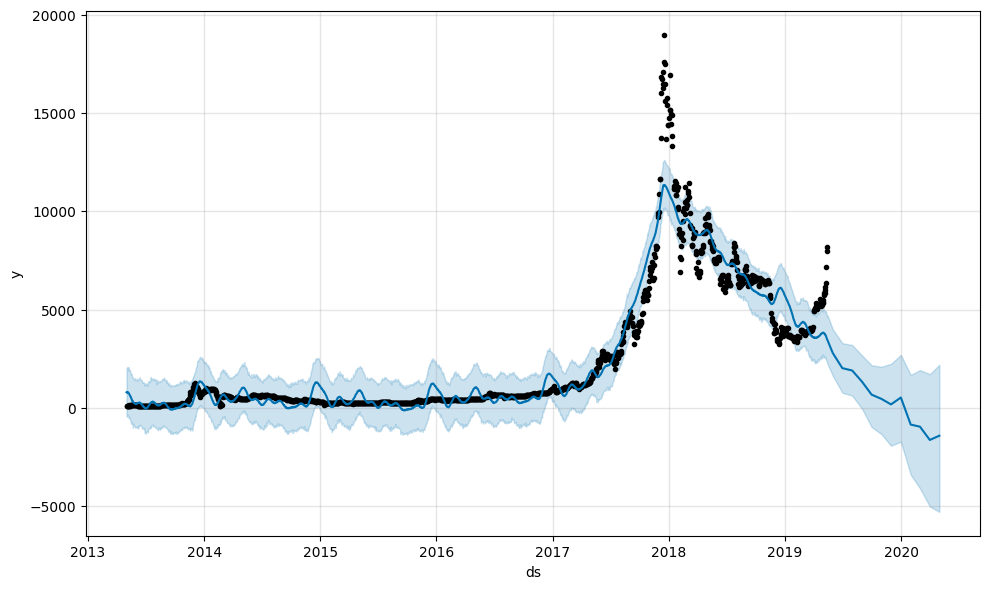

In [ ]:
df_btc_prophet = df_btc['BTC'].reset_index()
df_btc_prophet.columns = ['ds' , 'y']

model_btc_prophet = Prophet()
model_btc_prophet.fit(df_btc_prophet)

future_btc = model_btc_prophet.make_future_dataframe(periods = 12 , freq = 'M')
forecast_btc = model_btc_prophet.predict(future_btc)

model_btc_prophet.plot(forecast_btc)
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcfag4flf/uhmcceg9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcfag4flf/hs_nud7v.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=25429', 'data', 'file=/tmp/tmpcfag4flf/uhmcceg9.json', 'init=/tmp/tmpcfag4flf/hs_nud7v.json', 'output', 'file=/tmp/tmpcfag4flf/prophet_modelh9ap_ne4/prophet_model-20250211091501.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:15:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:15:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


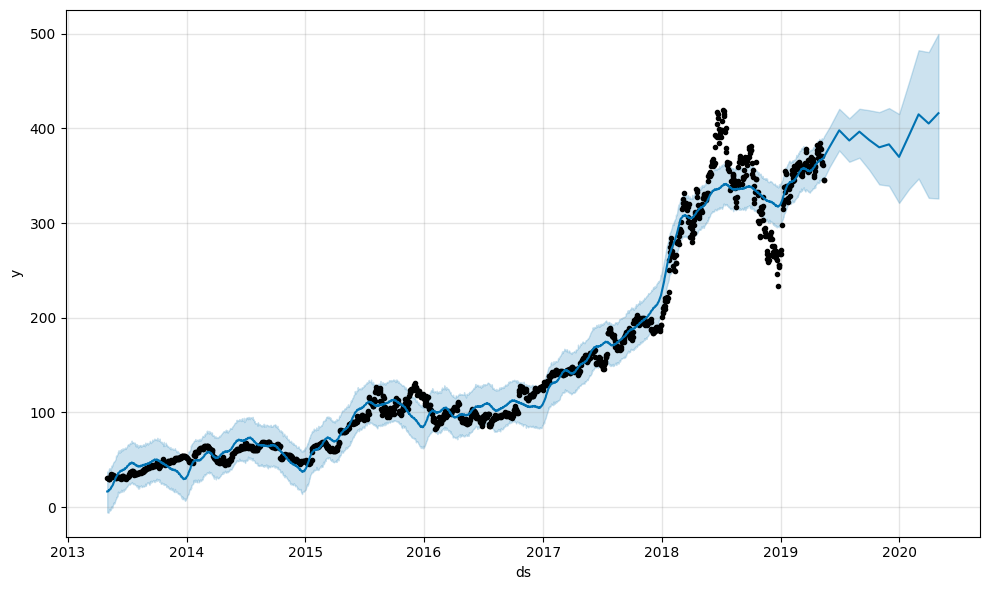

In [ ]:
df_nflx_prophet = df_nflx['NFLX'].reset_index()
df_nflx_prophet.columns = ['ds' , 'y']

model_nflx_prophet = Prophet()
model_nflx_prophet.fit(df_nflx_prophet)

future_nflx = model_nflx_prophet.make_future_dataframe(periods = 12 , freq = 'M')
forecast_nflx= model_nflx_prophet.predict(future_nflx)

model_nflx_prophet.plot(forecast_nflx)
plt.show()

In [ ]:
"""
Prophet evaluation
"""

y_true = df_amzn["AMZN"].iloc[-12:].values
y_pred = forecast_amzn["yhat"].iloc[-12:].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("AMZN -------")
print(f"Prophet MAE: {mae}")
print(f"Prophet RMSE: {rmse}")


y_true = df_dpz["DPZ"].iloc[-12:].values
y_pred = forecast_dpz["yhat"].iloc[-12:].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("DPZ -------")
print(f"Prophet MAE: {mae}")
print(f"Prophet RMSE: {rmse}")


y_true = df_nflx["NFLX"].iloc[-12:].values
y_pred = forecast_nflx["yhat"].iloc[-12:].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("NFLX -------")
print(f"Prophet MAE: {mae}")
print(f"Prophet RMSE: {rmse}")


y_true = df_btc["BTC"].iloc[-12:].values
y_pred = forecast_btc["yhat"].iloc[-12:].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("BTC -------")
print(f"Prophet MAE: {mae}")
print(f"Prophet RMSE: {rmse}")


AMZN -------
Prophet MAE: 79.06980297768364
Prophet RMSE: 107.20151984065492
DPZ -------
Prophet MAE: 22.540362548782667
Prophet RMSE: 23.996776775426806
NFLX -------
Prophet MAE: 24.79865875518981
Prophet RMSE: 33.80746271721724
BTC -------
Prophet MAE: 5879.741822296543
Prophet RMSE: 6291.830317768809


# **LSTM** + **XGB**

In [ ]:
df_amzn['AMZN_diff'].max()

128.5199580000001

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
df2_amzn = df_amzn[['AMZN']]
df2_amzn

,AMZN
Date,
2013-05-01,248.229996
2013-05-02,252.550003
2013-05-03,258.049988
2013-05-06,255.720001
2013-05-07,257.730011
...,...
2019-05-08,1917.770020
2019-05-09,1899.869995
2019-05-10,1889.979980


In [ ]:
Scaler = MinMaxScaler(feature_range = (0,1))
df_amzn_scaled = Scaler.fit_transform(df2_amzn)
df_amzn_scaled = pd.DataFrame(df_amzn_scaled , index = df2_amzn.index, columns=df2_amzn.columns)
df_amzn_scaled

,AMZN
Date,
2013-05-01,0.000000
2013-05-02,0.002412
2013-05-03,0.005482
2013-05-06,0.004181
2013-05-07,0.005303
...,...
2019-05-08,0.932037
2019-05-09,0.922045
2019-05-10,0.916523


In [ ]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i : i + time_steps])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)


data_array = df_amzn_scaled.values
time_steps = 60
X, y = create_sequences(data_array, time_steps)

print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")


Shape of X: (1460, 60, 1), Shape of y: (1460,)


In [ ]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


print(f"Training Data Shape: {X_train.shape}, {y_train.shape}")
print(f"Testing Data Shape: {X_test.shape}, {y_test.shape}")



Training Data Shape: (1168, 60, 1), (1168,)
Testing Data Shape: (292, 60, 1), (292,)


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(60, 1) , kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    LSTM(units=50, return_sequences=True , kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    LSTM(units=50, return_sequences=False ,kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    Dense(units=25),
    Dense(units=1)
])



optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer , loss='mean_squared_error')

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                       │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_13 (LSTM)                       │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_14 (LSTM)                       │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,101 (203.52 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - loss: 1.6603 - val_loss: 1.8499
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 1.5784 - val_loss: 1.6093
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 1.5159 - val_loss: 1.5313
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 1.4594 - val_loss: 1.4561
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 1.4053 - val_loss: 1.3813
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 1.3529 - val_loss: 1.3191
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 1.3029 - val_loss: 1.2693
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 1.2559 - val_loss: 1.2235
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 1.2102 - val_loss: 1.1762
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 1.1655 - val_loss: 1.1333
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 1.1227 - val_loss: 1.0920
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step 

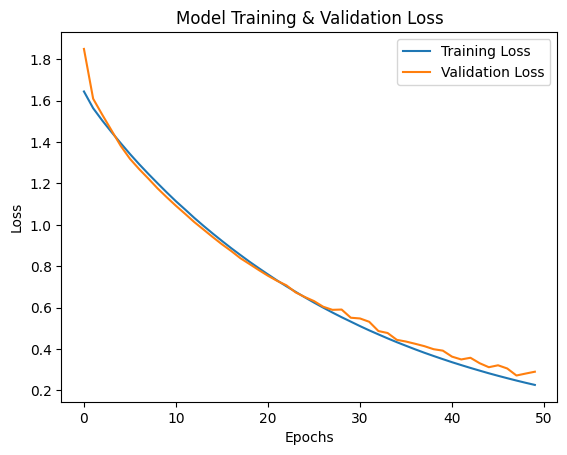

In [ ]:

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Training & Validation Loss')
plt.show()


In [ ]:
!pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt


def build_model(hp):
    model = Sequential()


    model.add(LSTM(
        units=hp.Choice('lstm_units', [32, 50, 100, 150]),
        return_sequences=True,
        input_shape=(60, 1),
        kernel_regularizer=l2(hp.Choice('l2_reg', [0.001, 0.01]))
    ))
    model.add(Dropout(hp.Choice('dropout_rate', [0.2, 0.3, 0.5])))


    model.add(LSTM(
        units=hp.Choice('lstm_units', [32, 50, 100, 150]),
        return_sequences=True
    ))
    model.add(Dropout(hp.Choice('dropout_rate', [0.2, 0.3, 0.5])))


    model.add(LSTM(units=hp.Choice('lstm_units', [32, 50, 100, 150])))
    model.add(Dropout(hp.Choice('dropout_rate', [0.2, 0.3, 0.5])))

    model.add(Dense(1))


    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', [0.001, 0.0005, 0.0001])),
        loss='mean_squared_error'
    )

    return model


In [ ]:
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    directory='hyperparam_tuning',
    project_name='stock_prediction'
)


stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test), callbacks=[stop_early])


best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Best LSTM Units: {best_hps.get('lstm_units')}
Best Dropout Rate: {best_hps.get('dropout_rate')}
Best Learning Rate: {best_hps.get('learning_rate')}
Best L2 Regularization: {best_hps.get('l2_reg')}
""")


Trial 90 Complete [00h 00m 54s]
val_loss: 0.0048508914187550545

Best val_loss So Far: 0.0016118217026814818
Total elapsed time: 01h 44m 47s

Best LSTM Units: 150
Best Dropout Rate: 0.2
Best Learning Rate: 0.001
Best L2 Regularization: 0.001



In [ ]:
# Build the best model with optimal hyperparameters
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
history = best_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[stop_early])



Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 26s 377ms/step - loss: 0.0182 - val_loss: 0.0043
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 322ms/step - loss: 0.0017 - val_loss: 0.0030
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 322ms/step - loss: 0.0011 - val_loss: 0.0053
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 322ms/step - loss: 9.1992e-04 - val_loss: 0.0095
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 319ms/step - loss: 9.0111e-04 - val_loss: 0.0028
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 331ms/step - loss: 9.0604e-04 - val_loss: 0.0024
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 340ms/step - loss: 8.4821e-04 - val_loss: 0.0024
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 338ms/step - loss: 0.0015 - val_loss: 0.0030
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - loss: 8.7480e-04 - val_loss: 0.0062
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 339ms/step - loss: 7.5995e-04 - val_loss: 0.0037
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 322ms/step - loss: 7.8903e-04 - val_loss: 0.0067
Epoch 12/50
3

In [ ]:
y_pred = best_model.predict(X_test)

# Inverse transform the predictions (since we scaled the data)
y_pred_rescaled = Scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_rescaled = Scaler.inverse_transform(y_test.reshape(-1, 1))

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step


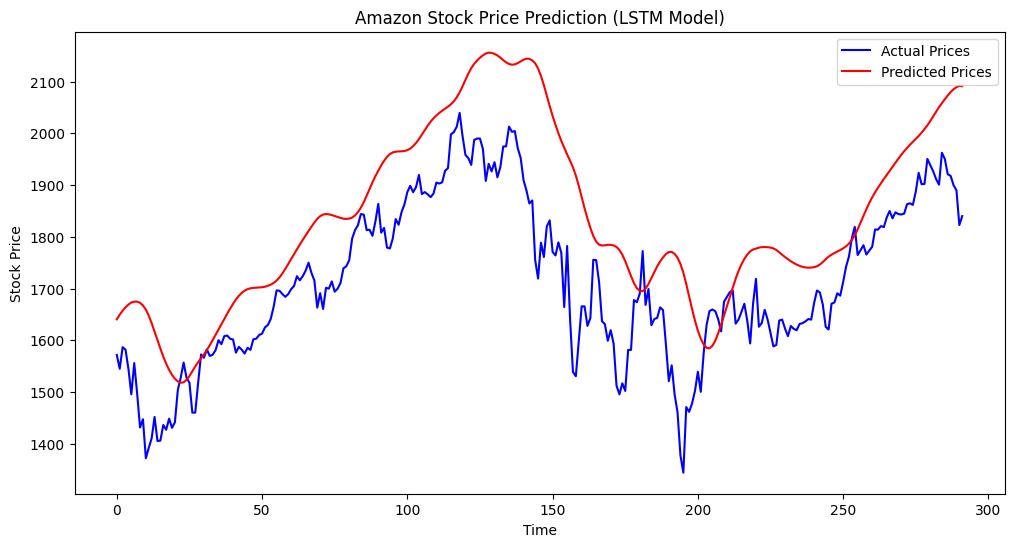

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label="Actual Prices", color='blue')
plt.plot(y_pred_rescaled, label="Predicted Prices", color='red')
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Amazon Stock Price Prediction (LSTM Model)")
plt.legend()
plt.show()

In [ ]:

mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)



# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")



Mean Absolute Error (MAE): 124.5779
Mean Squared Error (MSE): 22001.2731
Root Mean Squared Error (RMSE): 148.3283


In [ ]:
from keras_tuner import HyperParameters
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# ✅ Define Hyperparameter Tuning Model
def build_lstm(hp: HyperParameters):
    model = Sequential()

    # First LSTM Layer
    model.add(LSTM(
        units=hp.Int('units_1', min_value=50, max_value=300, step=50),
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2]),
        kernel_regularizer=l2(hp.Float('l2_reg', 0.0001, 0.01, sampling='log'))
    ))

    # Dropout Layer
    model.add(Dropout(hp.Float('dropout_rate', 0.1, 0.5, step=0.1)))

    # Second LSTM Layer
    model.add(LSTM(units=hp.Int('units_2', min_value=50, max_value=300, step=50)))

    # Output Layer
    model.add(Dense(1))

    # Compile Model
    model.compile(
        optimizer=Adam(hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
        loss='mse'
    )

    return model

# ✅ Create Hyperparameter Tuner
tuner = kt.BayesianOptimization(
    build_lstm,
    objective='val_loss',
    max_trials=50,
    directory='tuning_results'
)

# ✅ Split Data for Training & Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# ✅ Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ✅ Start Hyperparameter Search
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,  # ✅ Use a fixed batch size here, NOT hp.Int()
    callbacks=[early_stopping]
)


Trial 50 Complete [00h 00m 29s]
val_loss: 0.0001580671378178522

Best val_loss So Far: 0.00013260683044791222
Total elapsed time: 00h 27m 48s


In [ ]:
# Get the best hyperparameters found by the tuner
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the best model using the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)

# Train the best model on the full training set
best_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, callbacks=[early_stopping])


Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0248 - val_loss: 0.0026
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0015 - val_loss: 4.2918e-04
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.2609e-04 - val_loss: 3.4080e-04
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.5884e-04 - val_loss: 3.2145e-04
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.1779e-04 - val_loss: 2.8645e-04
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.7560e-04 - val_loss: 2.4525e-04
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.9980e-04 - val_loss: 2.4675e-04
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.7544e-04 - val_loss: 2.2640e-04
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.4145e-04 - val_loss: 2.1948e-04
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.7693e-04 - val_loss: 2.6251e-04
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.9257e-04

In [ ]:
# Extract features from the LSTM model (use the last hidden layer's output)
lstm_features_train = best_model.predict(X_train)  # Features for training
lstm_features_val = best_model.predict(X_val)      # Features for validation

# Reshape features if necessary
lstm_features_train = lstm_features_train.reshape(-1, 1)
lstm_features_val = lstm_features_val.reshape(-1, 1)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
import xgboost as xgb

# Initialize XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)

# Train XGBoost using LSTM's feature representations
xgb_model.fit(lstm_features_train, y_train)

# Predict with XGBoost
y_pred_xgb = xgb_model.predict(lstm_features_val)

# Evaluate XGBoost
from sklearn.metrics import mean_squared_error, r2_score

mse_xgb = mean_squared_error(y_val, y_pred_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)

print(f"XGBoost Mean Squared Error: {mse_xgb:.4f}")
print(f"XGBoost R² Score: {r2_xgb:.4f}")


XGBoost Mean Squared Error: 0.0001
XGBoost R² Score: 0.9955


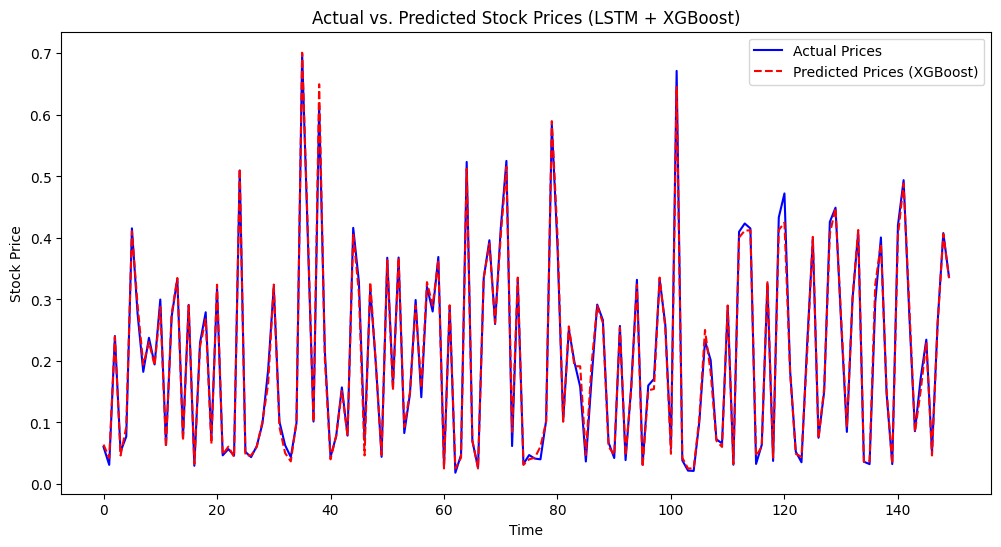

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_val, label="Actual Prices", color='blue')
plt.plot(y_pred_xgb, label="Predicted Prices (XGBoost)", color='red', linestyle='dashed')

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Actual vs. Predicted Stock Prices (LSTM + XGBoost)")
plt.legend()
plt.show()


In [ ]:
# Save the best LSTM model
best_model.save("lstm_model.h5")
